## A Hands-on Introduction to BioImage Simulation with DeepTrack2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIM-Net/SPAOM-CW20-DeepTrack/blob/main/CW20_Guigo_SPAOM2026.ipynb)
&nbsp;
[Repository](https://github.com/AIM-Net/SPAOM-CW20-DeepTrack)

Deep learning is used across microscopy, from well-established tasks such as cell counting and reconstructing trajectories in Single Particle Tracking (SPT), through segmentation and denoising, to problems still very much at the research frontier such as locating individual synapses in dense neuronal tissue. Training such models to perform well on experimental data usually requires collecting large amounts of it, which may be costly and not always available. Furthermore, it involves an annotation process that can be tedious and error-prone.

In this tutorial we will follow a different route: rather than annotating real images, we will simulate them. We will use [DeepTrack2](https://github.com/DeepTrackAI/DeepTrack2), an open-source library that uses physics-informed image simulation to generate labelled training data on demand, with known, exact ground truth and no manual annotation at all.

We will build the simulation step by step:
- Define a simple scatterer acting as a point particle and image it through a microscopy setup
- Add realistic sensor noise, and animate the particle with random motion such as Brownian dynamics
- Image the same object with different microscopy modalities
- Build up to more complex objects: cells, then bacteria, then two-color images of synapses
- Compose the full pipeline (scatterer → optics → noise) into a training set for a U-Net that counts cells, trained in a companion notebook
- Discuss which simulation choices matter most when moving from simulated to experimental data

### 0. Setup

If you are running on **Google Colab / Kaggle**, uncomment and run the next cell. Locally, install the packages once in your environment (`pip install -e .` from the repository root).

In [5]:
# !pip install deeptrack deeplay

In [6]:
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(2026)  # Makes a top-to-bottom run reproducible.

### 1. Simulating images

Generating realistic synthetic images is an effective way to train and validate deep learning models for digital microscopy. In DeepTrack2, an image is built by composing **features**, each one a rule for producing data.

Some features **create** something from nothing, such as a scatterer that defines an object. Others **transform** what they are given: an optical device turns a sample into an image, and a noise feature corrupts an image into a more realistic one.

#### 1.1 Point particle

We start with the simplest object: a point particle, i.e. an object smaller than the resolution of the microscope. This is the case of a diffraction-limited particle such as a single fluorophore. The code below creates one with the class `PointParticle` (a child of `Feature`), setting its properties `position` and `intensity`:

In [7]:
IMAGE_SIZE = 64

particle = dt.PointParticle(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2) * dt.units.pixel,
    intensity=40,
)

We use `dt.units.pixel` to state the unit of the property, although most of the time this can be omitted. Here we also choose the size of the image in pixels and place the particle in the center.

Once the object is defined, we need an optical device through which it is viewed to generate the image. In this case we define a fluorescence setup, choosing the numerical aperture (NA) of the objective, the wavelength of the emitted light, the magnification of the system, the pixel size of the camera (`resolution`), and the output region (in pixels) of the generated image.

In [8]:
fluorescence_microscope = dt.Fluorescence(
    NA=1.4,
    wavelength=680 * dt.units.nm,
    magnification=60,
    resolution=6.5 * dt.units.um,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

Calling the microscope on the particle does **not** produce an image. It builds a new feature, representing the particle *as seen through* this microscope:

In [9]:
imaged_particle = fluorescence_microscope(particle)

print(type(imaged_particle).__name__)  # A feature, not an image.

Microscope


Nothing has been computed yet. To obtain the actual image we **resolve** the feature, either by calling it or with the equivalent `.resolve()` method, which returns a NumPy array of shape `(height, width, channels)`:

Type: ndarray, shape: (64, 64, 1)


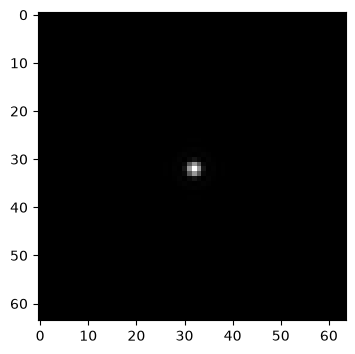

In [10]:
image = imaged_particle.resolve()  # Equivalent to imaged_particle().

print(f"Type: {type(image).__name__}, shape: {image.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(image[..., 0], cmap="gray")

#### 1.2 Multiple particles

Properties can also take functions instead of fixed values, which DeepTrack2 evaluates every time a new image is generated. Here we randomize the position, the intensity, and the depth `z` with respect to the focal plane:

In [11]:
particle = dt.PointParticle(
    position=lambda: np.random.uniform(4, IMAGE_SIZE-4, size=2),
    intensity=lambda: np.random.uniform(20, 60),
    z=lambda: np.random.uniform(-0.1, 0.1) * dt.units.um,
)

DeepTrack2 allows you to evaluate a feature multiple times using the `^` operator. Each time it is evaluated this way a new set of properties is used, which makes for a very convenient way to resolve multiple particles. We can use this to simulate a population of point emitters and image it through the fluorescent microscope:

<Axes: >

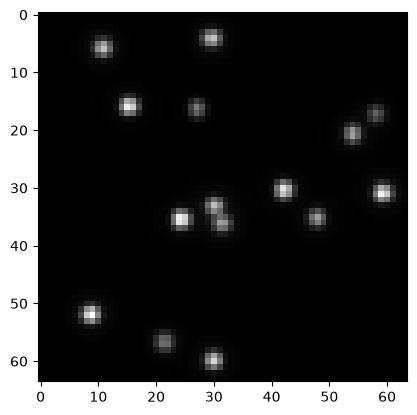

In [12]:
N_PARTICLES = 15

point_emitters = particle ^ N_PARTICLES

imaged_point_emitters = fluorescence_microscope(point_emitters)

imaged_point_emitters.plot(cmap="gray")

Re-running the cell gives the same image every time: the sampled values are stored as properties, since they are the ground truth of that image. If we want to resample the whole pipeline we can use the `.update()` method, e.g. `imaged_point_emitters.update().plot(cmap="gray")`.

#### 1.3 Adding noise

We now build our first **pipeline**, chaining features with the `>>` operator so that the output of each one becomes the input of the next. We use it to add noise to the image.

Real images are noisy, and in fluorescence the main contribution is usually **shot noise**: photons arrive at random, so the number collected by a pixel follows a Poisson distribution. We reproduce it with `dt.Poisson`:

<Axes: >

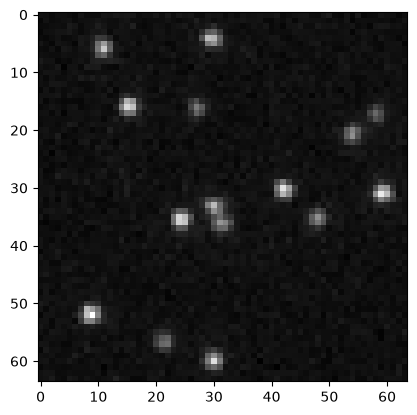

In [ ]:
experimental_image = (
    fluorescence_microscope(point_emitters)
    >> dt.Background(offset=0.1)
    >> dt.Poisson(snr=15, background=0.1)
)
experimental_image.plot(cmap="gray")

Since we did not call `.update()`, the emitters keept the positions sampled in 1.2 and we only added the noise.

#### 1.4 Retrieve properties

Training also needs labels, and since we generated the image ourselves they are already stored in the properties of the scatterers. `dt.TakeProperties` collects a property across every instance of a feature, and the `&` operator stacks the image and its labels into a single pipeline, resolved from the same sample:

(-0.5, 63.5, 63.5, -0.5)

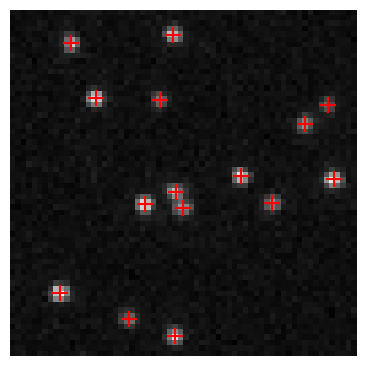

In [14]:
labelled_pipeline = experimental_image & dt.TakeProperties(experimental_image, "position")

image, *positions = labelled_pipeline()  # Resolve image and labels together.
positions = np.array(positions)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(np.squeeze(image), cmap="gray")
plt.scatter(positions[:, 1], positions[:, 0], s=120, marker="+", c="r")
plt.axis("off")

Each marker sits on the particle that generated it, with sub-pixel accuracy and no manual annotation.

#### 1.5 Adding dynamics

Now we will add random motion: particles in a fluid are kicked around by the surrounding molecules and diffuse following a random walk, known as **Brownian motion**. We make a property evolve over time with `.to_sequential()`, which takes a rule computing its new value from the `previous_value`. Instead of creating new particles, we let the emitters from the previous sections diffuse for 50 frames:

In [15]:
D = 0.05  # Diffusion coefficient (um^2/s).
FRAME_TIME = 0.03  # Time between frames (s).
N_FRAMES = 50
PIXEL_SIZE_UM = 6.5 / 60  # resolution / magnification.

STEP_SIGMA_PX = np.sqrt(2 * D * FRAME_TIME) / PIXEL_SIZE_UM
print(f"Step size per frame and axis: {STEP_SIGMA_PX:.2f} px")


def brownian_step(previous_value, **kwargs):
    return previous_value + np.random.normal(0, STEP_SIGMA_PX, size=2)


# Starting point: the emitters we already generated.
starting_positions = np.array(dt.TakeProperties(point_emitters, "position")())
starting_intensities = np.array(dt.TakeProperties(point_emitters, "intensity")())

diffusing_particle = dt.PointParticle(
    position=lambda _ID: starting_positions[_ID[-1]],
    intensity=lambda _ID: starting_intensities[_ID[-1]],
).to_sequential(position=brownian_step)

diffusing_particles = diffusing_particle ^ N_PARTICLES

movie = dt.Sequence(
    fluorescence_microscope(diffusing_particles) + 0.1
    >> dt.Poisson(snr=15, background=0.1),
    sequence_length=N_FRAMES,
)

Step size per frame and axis: 0.51 px


Frames: (50, 64, 64) | Trajectories: (15, 50, 2)


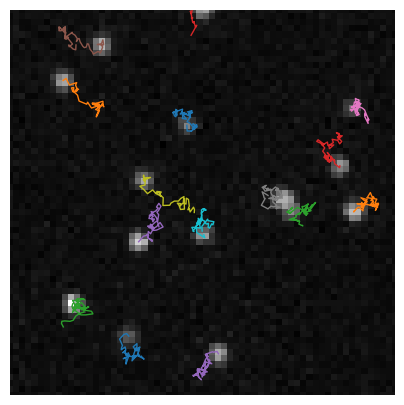

In [16]:
frames = np.array(movie.update()())[..., 0]
trajectories = np.array(dt.TakeProperties(diffusing_particles, "position")())
print("Frames:", frames.shape, "| Trajectories:", trajectories.shape)

plt.figure(figsize=(5, 5))
plt.imshow(frames[-1], cmap="gray")
for trajectory in trajectories:
    plt.plot(trajectory[:, 1], trajectory[:, 0], lw=1)
plt.xlim(0, IMAGE_SIZE - 1)
plt.ylim(IMAGE_SIZE - 1, 0)
plt.axis("off")
plt.show()

The lines are the exact path each emitter took, and they end on the particles of the last frame. These are the ground-truth trajectories a tracking algorithm would try to recover from the movie alone. Let's play it:

In [18]:
# Play the movie (it may take a few seconds to render).
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(4, 4))
frame_plot = ax.imshow(frames[0], cmap="gray", vmin=frames.min(), vmax=frames.max())
ax.axis("off")
anim = animation.FuncAnimation(
    fig, lambda t: frame_plot.set_data(frames[t]), frames=N_FRAMES, interval=50,
)
plt.close(fig)
HTML(anim.to_jshtml())

#### 1.6 Scatterers

DeepTrack2 describes every object in the sample as a **scatterer**, which defines **where** the object is (`position`, `z`) and **what shape** it has. The name comes from coherent techniques such as brightfield, where the object physically **scatters** light and the contrast comes from its `refractive_index`. In fluorescence there is no scattering: the object **emits** light, the relevant property is its `intensity`, and the refractive index is ignored.

Scatterers come in two families, which differ in *what they hand over to the optics*:

- A **`VolumeScatterer`** returns a **3D voxel volume**, i.e. pure geometry. The optics then propagate light through that volume slice by slice, so diffraction and defocus are computed by the optical device. `PointParticle`, `Sphere` and `Ellipsoid` are all of this kind, as is any custom shape you write yourself (we will do that in section 3).
- A **`FieldScatterer`** skips the geometry and returns the **complex field already scattered by the object**, computed from **Mie theory**, which solves Maxwell's equations exactly for a sphere. `MieSphere` and `MieStratifiedSphere` are the two available. They are exact but only for spheres, and since they need an incident field to scatter, they cannot be used with fluorescence.

In both cases the scatterer only describes the object: it is the optics that decide which physics applies.

To make that concrete: an `Ellipsoid` is a `VolumeScatterer`, so what it hands over is a block of voxels with hard edges. All the blur in the final image comes from the optics.

In [ ]:
ellipsoid = dt.Ellipsoid(
    position=(32, 32),
    radius=(1.5, 0.8, 0.8) * dt.units.um,
    rotation=np.pi / 5,
    intensity=3,
)

# Imaging also fixes the voxel grid, so resolve the image first.
image = np.asarray(fluorescence_microscope(ellipsoid).resolve())
volume = np.asarray(ellipsoid.resolve().array)

print(f"scatterer: {volume.shape} voxels -> image: {image.shape}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, panel, title in [
    (axes[0], volume.max(axis=2), "Scatterer (max over z)"),
    (axes[1], volume[:, :, volume.shape[2] // 2], "Central z slice"),
    (axes[2], image[..., 0], "Imaged through the optics"),
]:
    ax.imshow(panel, cmap="gray", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

#### 1.7 Imaging modalities

Since the scatterer and the optics are independent, the same object can be imaged with any of the five modalities that DeepTrack2 implements:

- `Fluorescence`: incoherent, the object emits light (`intensity`).
- `Brightfield`: coherent, transmitted light delayed by the object (`refractive_index`).
- `Holography`: the same propagation as brightfield, used to reconstruct the complex field.
- `ISCAT`: the scattered field interfering with a reference beam.
- `Darkfield`: only the scattered light, with the unscattered background suppressed.

All of them share the same optical parameters, so we define them once:

In [19]:
optics_parameters = dict(
    NA=1.2,
    wavelength=630 * dt.units.nm,
    magnification=60,
    resolution=6.5 * dt.units.um,
    refractive_index_medium=1.33,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

A `MieSphere` computes the scattered field exactly from Mie theory. In **darkfield** the unscattered illumination is removed, so the sphere appears bright on a dark background:

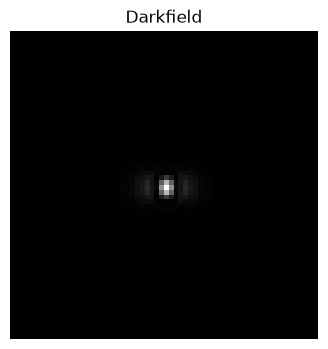

In [20]:
mie_sphere = dt.MieSphere(
    position=(32, 32),
    radius=0.5 * dt.units.um,
    refractive_index=1.45,
)

darkfield_image = dt.Darkfield(**optics_parameters)(mie_sphere).resolve()

plt.figure(figsize=(4, 4))
plt.imshow(darkfield_image[..., 0], cmap="gray")
plt.title("Darkfield")
plt.axis("off")
plt.show()

In **ISCAT** the scattered field interferes with a reference beam, which produces the characteristic dark core surrounded by rings:

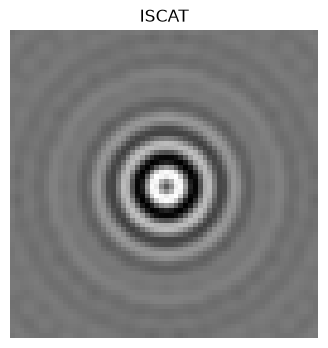

In [21]:
iscat_image = dt.ISCAT(**optics_parameters)(mie_sphere).resolve()

plt.figure(figsize=(4, 4))
plt.imshow(iscat_image[..., 0], cmap="gray")
plt.title("ISCAT")
plt.axis("off")
plt.show()

Coherent modalities also accept an ordinary volume scatterer such as a `Sphere`. DeepTrack2 then warns that the field is propagated with a weak-phase approximation instead of the exact Mie solution, which is a reasonable trade-off for weakly scattering objects such as cells:

/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/deeptrack/optical/optics.py:1878: UserWarning: Brightfield imaging from ScatteredVolume assumes a weak-phase / projection approximation. Use ScatteredField for physically accurate brightfield simulations.
  warnings.warn(


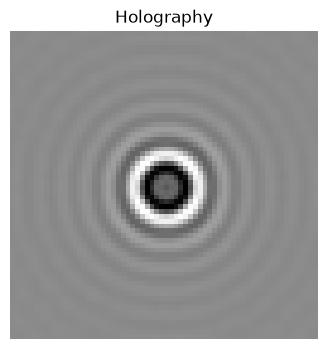

In [22]:
sphere = dt.Sphere(
    position=(32, 32),
    radius=0.5 * dt.units.um,
    refractive_index=1.45,
)

holography_image = dt.Holography(**optics_parameters)(sphere).resolve()

plt.figure(figsize=(4, 4))
plt.imshow(holography_image[..., 0], cmap="gray")
plt.title("Holography")
plt.axis("off")
plt.show()

### Exercises

**Exercise 1. Brightfield imaging of a sphere.**

Define a `dt.Sphere` (`position`, `radius`, `refractive_index`) and image it with `dt.Brightfield` in a pipeline that also adds noise. Then play with the optical setup: what happens to the contrast as the sphere's `refractive_index` approaches `refractive_index_medium`? And when you defocus it (`z`), or change `NA` and `wavelength`?

In [23]:
# Your code here.

**Exercise 2. A population of aberrated ellipsoids.**

Define 5 `dt.Ellipsoid` scatterers with random positions and orientations (`rotation`), image them with `dt.Fluorescence` and add noise. Then aberrate the optics with `pupil=dt.Astigmatism(coefficient=2)` and compare. Other options: `dt.SphericalAberration`, `dt.HorizontalComa`, `dt.Zernike`.

*Hint:* `radius` takes the three semi-axes, e.g. `radius=(2e-6, 0.8e-6, 0.8e-6)`, and you can build the population with `^` as in 1.2.

In [24]:
# Your code here.

### 2. Simulating cells

Real objects are rarely perfect ellipsoids: cells have irregular outlines and visible internal structure. Since features can be composed freely, we can build such objects up step by step. Here we reproduce the stained nuclei of the [BBBC039](https://bbbc.broadinstitute.org/BBBC039) dataset, starting by looking at the real images we want to imitate together with their annotated masks:

In [25]:
import os

import torch
from PIL import Image

if not os.path.exists("cell_counting_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/cell_counting_dataset")

root = os.path.join("cell_counting_dataset", "cell nuclei")
image_dir = os.path.join(root, "images")
mask_dir = os.path.join(root, "masks")

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

torch.Size([520, 696]) torch.Size([520, 696])


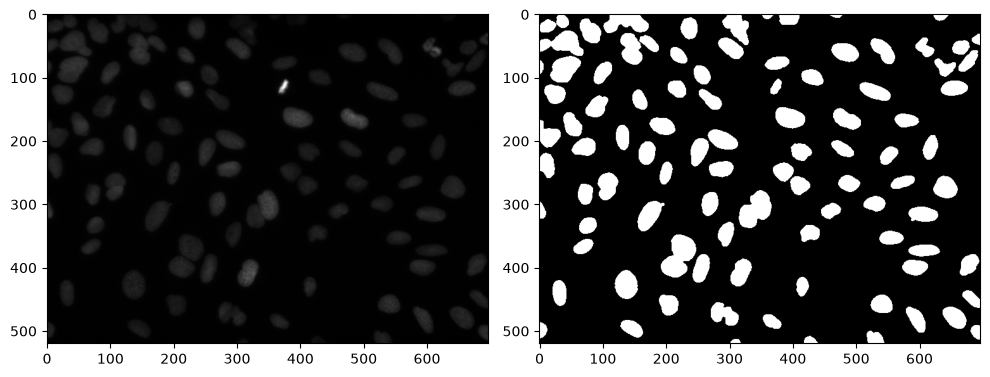

In [26]:
def load_pair(idx):
    """Loads an image with ground truth from file."""
    image = Image.open(os.path.join(image_dir, image_files[idx]))
    image = np.array(image, dtype=np.float32)
    image = image/image.max()
    image = torch.from_numpy(image)

    mask = Image.open(os.path.join(mask_dir, mask_files[idx])).convert("RGB")
    mask = np.array(mask, np.uint8)
    mask = mask.max(axis=2)
    mask = (mask > 0).astype(np.float32)
    mask = torch.from_numpy(mask)

    return image, mask

image, mask = load_pair(0)
print(image.shape, mask.shape)

# Plot a sample.
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, cmap="gray")
axs[1].imshow(mask, cmap="gray")
plt.tight_layout()
plt.show()

#### 2.1 Generating cell-like scatterers

To a first approximation a nucleus is an ellipsoid, so we draw its area, elongation, orientation and brightness at random. The `NA` of the microscope is randomized too, since focus and optical quality vary from one experimental image to the next:

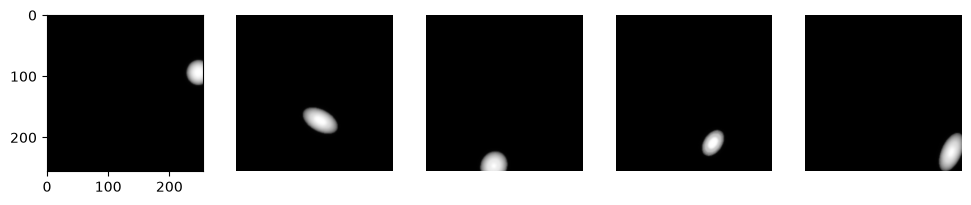

In [118]:
IMAGE_SIZE = 256

# Helper function to keep axis within reasonable parameters.
def random_ellipse_axes():
    """Return the three axes of an ellipse."""
    ellipse_area = (np.random.uniform(3, 4)) ** 2
    radius_ratio = np.random.uniform(1, 1.5)
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = np.sqrt(ellipse_area) * np.random.uniform(0.2, 0.4)
    return (major_axis, minor_axis, z_axis)* dt.units.um

# Define the ellipse.
ellipse = dt.Ellipsoid(
    radius = random_ellipse_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(5, IMAGE_SIZE - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

# Define the microscope.
optics = dt.Fluorescence(
    resolution=1e-6,
    magnification=6,
    wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Image the ellipses with a fluorescence microscope.
sim_im_pip = optics(ellipse)

# Plot some samples.
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    sim_im_pip.update()
    image = sim_im_pip()
    ax.imshow(image, cmap="gray")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()

#### 2.2 Simulating realistic cells

Plain ellipsoids are too smooth and too uniform to pass for real nuclei. Two additions close most of the gap: an **elastic transformation**, which bends the outline into something irregular, and **texture**, obtained by multiplying the nuclei with Poisson noise blurred at three different length scales. We then place them so that they do not overlap, image them, and finish by matching the background level and intensity range of the real data:

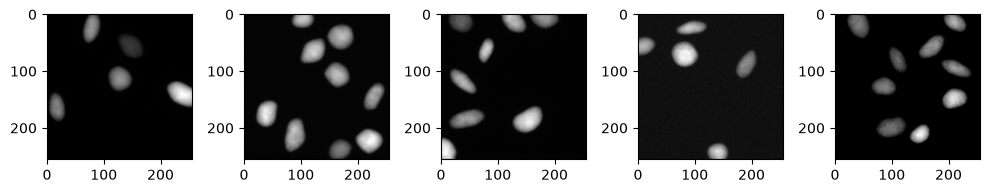

In [119]:
ellipse = dt.Ellipsoid(
    radius = random_ellipse_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(5, IMAGE_SIZE - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

# Add elastic transformations.
synthetic_nuclei = (
    (ellipse ^ (lambda: np.random.randint(5, 10)))
    >> dt.Pad(px=(10, 10, 10, 10), keep_size=False)
    >> dt.ElasticTransformation(alpha=100, sigma=10, order=1)
    >> dt.CropTight()
)

# Define Poisson noise and Gaussian blur.
long_range_noise = (synthetic_nuclei >> dt.Poisson(snr=0.2)
                    >> dt.GaussianBlur(sigma=3.5))
short_range_noise = (synthetic_nuclei >> dt.Poisson(snr=1.0)
                     >> dt.GaussianBlur(sigma=1.5))
random_range_noise = (
    synthetic_nuclei
    >> dt.Poisson(snr=lambda: np.random.uniform(0.5, 1.5))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.75, 1.5))
)

# Combine the augmentations.
noisy_synthetic_nuclei = (
    synthetic_nuclei
    * (long_range_noise + short_range_noise + random_range_noise) / 3
)

# Ensure non-overlapping cells.
non_overlap_nuclei = dt.NonOverlapping(noisy_synthetic_nuclei, min_distance=2)

# Define the microscope.
optics = dt.Fluorescence(
    resolution=1e-6, magnification=6, wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Define simulation pipeline with some background noise.
sim_im_pip = (optics(non_overlap_nuclei)
              >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.1))
              >> dt.Divide(lambda: np.random.uniform(14, 20))
              >> dt.Add(lambda: np.random.uniform(-0.05, 0.15))
              >> dt.Clip(0, 1) >> dt.AsType("float"))

# Plot some samples.
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    sim_im_pip.update()
    image = sim_im_pip()
    ax.imshow(image, cmap="gray")

plt.tight_layout()
plt.show()

#### Training a U-Net

The simulation is now ready: this pipeline produces realistic nuclei together with their exact ground truth, which is everything a supervised model needs. Training a U-Net on it, and testing it on the real BBBC039 images, is done in a separate notebook so that this one stays focused on the simulation:

- [`UNet-train.ipynb`](UNet-train.ipynb), in this repository.
- Or the DeepTrack2 tutorial [DTEx215: cell counting](https://github.com/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx215_cell_counting.ipynb), which covers the same ground in more detail.

### 3. Simulating bacteria

Cells were still close to the built-in shapes, but a rod-shaped bacterium is not. When no built-in shape fits, we write our own: a custom scatterer subclasses `VolumeScatterer` and implements `get()`, which returns the **3D voxel volume** of a single object. DeepTrack2 takes care of placing it in the sample, rotating it and imaging it, exactly as for any built-in scatterer.

#### 3.1 A custom Bacillus scatterer

`Bacillus` renders a rod as a **hollow shell**: a capsule, i.e. a cylinder with hemispherical caps, with a wave-like bend along its length, from which a slightly smaller inner capsule is subtracted so that only the cell envelope remains. That shell is what gives the characteristic bright outline in brightfield.

In [120]:
from deeptrack import units as u
from deeptrack.backend.units import ConversionTable
from deeptrack.optical.scatterers import VolumeScatterer
from skimage.segmentation import find_boundaries

BACTERIA_SIZE = 256
BACTERIA_RESOLUTION = 1e-7  # 100 nm/px.

Unstained bacteria are usually observed in transmission, so we image them in brightfield and darkfield, where the contrast comes from the refractive index:

In [121]:
class Bacillus(VolumeScatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
        self,
        radius=0.4e-6,
        length=2e-6,
        rotation=(0, 0, 0),
        bend=0,
        refractive_index=1.38,
        **kwargs,
    ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            bend=bend,
            refractive_index=refractive_index,
            **kwargs,
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius is scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        bend,
        voxel_size,
        **kwargs,
    ):

        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 / voxel_size[2]) + rad_ceil
        ceil = int(max(rad_ceil, len_ceil))

        # Create the grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Apply wave-like bending along the length of the bacillus
        lateral_offset_x = bend * np.cos(np.pi * YR / length)
        XR -= lateral_offset_x

        # Cylinder mask
        cyl_mask = ((XR**2 / radius**2 + ZR**2 / radius**2) < 1) & (
            np.abs(YR) < (length / 2)
        )
        # Hemispherical caps
        cap_mask = (
            XR**2 + ZR**2 + (np.abs(YR) - (length / 2)) ** 2
        ) < radius**2

        # Combine cylinder with end-caps to form the full bacillus shape
        mask = cyl_mask | cap_mask

        # Hollow out an inner capsule to leave only the cell envelope (shell)
        inner_radius = radius * 0.6
        inner_length = length * 0.9

        cyl_mask_in = ((XR**2 / inner_radius**2 + ZR**2 / inner_radius**2) < 1) & (
            np.abs(YR) < (inner_length / 2)
        )
        cap_mask_in = (
            XR**2 + ZR**2 + (np.abs(YR) - (inner_length / 2)) ** 2
        ) < inner_radius**2
        mask_in = cyl_mask_in | cap_mask_in

        shell = mask & ~mask_in
        return shell.astype(float)


#### 3.2 Optics

In [122]:
optics_bf = dt.Brightfield(
    resolution=BACTERIA_RESOLUTION, magnification=1,
    NA=1.2, refractive_index_medium=1.33,
    output_region=(0, 0, BACTERIA_SIZE, BACTERIA_SIZE),
)

optics_df = dt.Darkfield(
    resolution=BACTERIA_RESOLUTION, magnification=1,
    NA=1.45, refractive_index_medium=1.33,
    output_region=(0, 0, BACTERIA_SIZE, BACTERIA_SIZE),
)

#### 3.3 The sample and its mask

A population of bacilli with random positions, orientations, lengths, bends and refractive indices. As always, `dt.SampleToMasks` builds the ground-truth mask from the same scatterers that produce the image:

In [123]:
MAX_BEND = 2e-7

bacillus = Bacillus(
    position=lambda: np.random.uniform(10, BACTERIA_SIZE - 10, 2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    length=lambda: np.random.uniform(1.4e-6, 2.2e-6),
    bend=lambda: (np.random.rand() - 0.5) * 2 * MAX_BEND,
    refractive_index=lambda: np.random.uniform(1.38, 1.42),
)

bacteria = bacillus ^ (lambda: np.random.randint(5, 10))


def binary_mask(volume):
    return np.sum(volume, -1, keepdims=True) > 0


mask = bacteria >> dt.SampleToMasks(
    lambda: binary_mask,
    output_region=(0, 0, BACTERIA_SIZE, BACTERIA_SIZE),
    merge_method="or",
)

#### 3.4 Imaging the sample

/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/deeptrack/optical/optics.py:2345: UserWarning: Darkfield imaging from ScatteredVolume is a very rough approximation. Use ScatteredField for physically meaningful darkfield simulations.
  warnings.warn(
/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/deeptrack/optical/optics.py:2379: UserWarning: Approximating darkfield contrast from refractive index. Result is non-physical and qualitative only.
  warnings.warn(


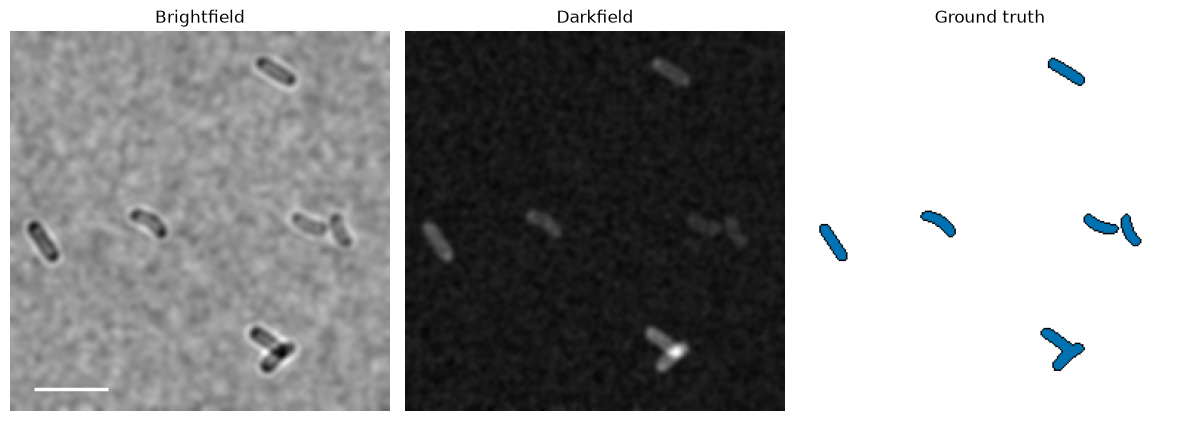

In [124]:
pip_bf = optics_bf(bacteria) >> dt.Gaussian(sigma=0.035) >> dt.GaussianBlur(sigma=2.4)
pip_df = optics_df(bacteria) >> dt.Gaussian(sigma=0.00135) >> dt.GaussianBlur(sigma=1.6)

image_bf, image_df, bacteria_mask = (pip_bf & pip_df & mask).update()()
bacteria_mask = bacteria_mask.squeeze().astype(bool)

# Ground truth: Wong's colorblind-safe blue, outlined in black.
ground_truth = np.ones((*bacteria_mask.shape, 3), dtype=np.float32)
ground_truth[bacteria_mask] = (0.0, 114 / 255, 178 / 255)
ground_truth[find_boundaries(bacteria_mask, mode="inner")] = 0.0

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, image, title in [
    (axes[0], image_bf.squeeze(), "Brightfield"),
    (axes[1], image_df.squeeze(), "Darkfield"),
    (axes[2], ground_truth, "Ground truth"),
]:
    ax.imshow(image, cmap=None if image.ndim == 3 else "gray")
    ax.set_title(title)
    ax.axis("off")

# 5 um scale bar on the brightfield panel.
scale_bar_px = 5.0 / (BACTERIA_RESOLUTION * 1e6)
axes[0].plot([BACTERIA_SIZE * 0.06, BACTERIA_SIZE * 0.06 + scale_bar_px],
             [BACTERIA_SIZE * 0.94] * 2,
             color="white", linewidth=2.5, solid_capstyle="butt")

plt.tight_layout()
plt.show()

### 4. Confocal images of synapses

A synapse is marked by two proteins, one on each side of the cleft, stained in different colors. The two channels are therefore **not independent**: the puncta come in pairs, share a shape and an orientation, and sit a few hundred nanometers apart.

This is what we are trying to reproduce, a two-color confocal image of neurons in culture:

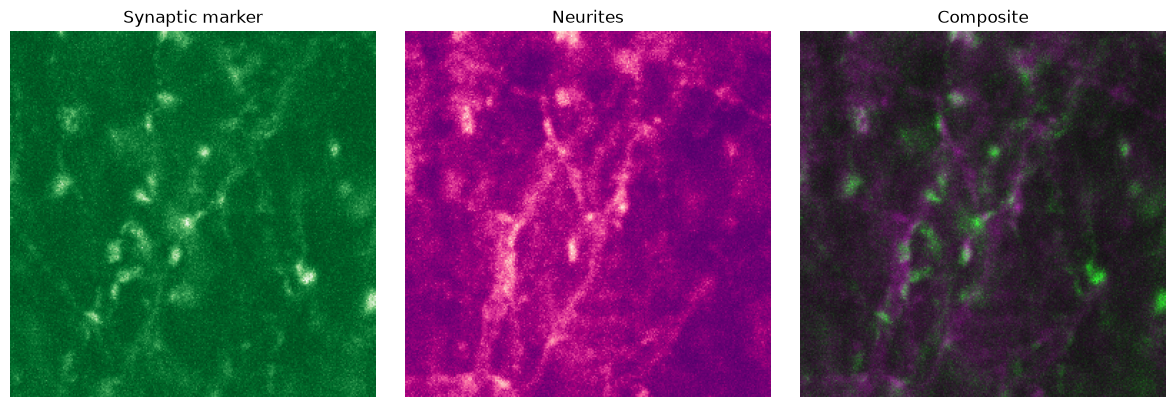

In [125]:
real = Image.open("figures/neuron-synapses.tif")
real_channels = []
for frame in range(real.n_frames):
    real.seek(frame)
    real_channels.append(np.array(real.convert("L"), dtype=np.float32))
real_green, real_magenta = real_channels

real_composite = np.stack([real_magenta, real_green, real_magenta], axis=-1)
real_composite /= real_composite.max()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, image, title, cmap in [
    (axes[0], real_green, "Synaptic marker", "Greens_r"),
    (axes[1], real_magenta, "Neurites", "RdPu_r"),
    (axes[2], real_composite, "Composite", None),
]:
    ax.imshow(image, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

The green channel shows the synaptic marker as bright puncta, the magenta one the neurites they sit on. *Image courtesy of Mercè Izquierdo-Serra (Universitat de Barcelona).*

We build this by defining an anchor punctum and deriving both channels from it, shifted in opposite directions along the same axis. Each channel is then imaged by its own `dt.Fluorescence` at its own emission wavelength, over a background of out-of-focus filaments, and both are resolved together so that the images and their masks always match.

In [126]:
from scipy.ndimage import gaussian_filter

from deeptrack.backend.units import get_active_voxel_size

SYNAPSE_SIZE = 160
SYNAPSE_RESOLUTION = 1e-7  # 100 nm/px, Nyquist-sampled for NA = 1.3 at these wavelengths.
OFFSET_FRACTION_RANGE = (0.0, 0.5)  # Cleft width, as a fraction of the punctum radius.
SNR_RANGE = (3.0, 3.0)

#### 4.1 Background textures

Two helpers generate the background the puncta sit on: a smooth, slowly varying intensity, and a layer of randomly curved filaments standing in for out-of-focus neurites. Both are wrapped in `dt.Value`, which turns a function returning an array into a feature. A third helper draws the three semi-axes of a punctum at a realistic sub-micron scale.

In [127]:
def create_background(scale=8.0, inty=0.20, size=SYNAPSE_SIZE):
    bg = np.random.standard_normal((size, size, 1)).astype(np.float32)
    bg = inty * gaussian_filter(bg, sigma=scale)
    bg[bg < 0] = 0
    return bg.astype(np.float32)


def make_bg(scale=8.0, inty=0.20, size=SYNAPSE_SIZE):
    return dt.Value(lambda: create_background(scale=scale, inty=inty, size=size))


def create_fil_background(n_filaments=20, fil_length=40, fil_width=1.5, fil_intensity=0.3,
                           size=256, curvature=0.05):
    fil_layer = np.zeros((size, size), dtype=np.float32)
    for _ in range(n_filaments):
        r0 = np.random.randint(0, size)
        c0 = np.random.randint(0, size)
        angle = np.random.uniform(0, np.pi)
        length = np.random.randint(fil_length // 2, fil_length)
        r, c = float(r0), float(c0)
        for t in range(int(length)):
            angle += np.random.normal(0, curvature)  # gentle random walk in direction
            r += np.sin(angle)
            c += np.cos(angle)
            ri, ci = int(r), int(c)
            if 0 <= ri < size and 0 <= ci < size:
                fil_layer[ri, ci] += 1.0
    fil_layer = gaussian_filter(fil_layer, sigma=fil_width)
    if fil_layer.max() > 0:
        fil_layer = fil_layer / fil_layer.max() * fil_intensity
    return fil_layer[..., np.newaxis].astype(np.float32)


def make_fil(n_filaments=20, fil_length=40, fil_width=1.5, fil_intensity=0.3, size=SYNAPSE_SIZE):
    return dt.Value(lambda: create_fil_background(
        n_filaments=n_filaments, fil_length=fil_length,
        fil_width=fil_width, fil_intensity=fil_intensity, size=size,
    ))


def random_ellipsoid_axes():
    # Corrected to true sub-micron synaptic-punctum scale (~0.2-0.8 um footprint).
    ellipse_area = (np.random.uniform(0.2, 0.8)) ** 2
    radius_ratio = np.random.uniform(0.7, 1.4)
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = np.sqrt(ellipse_area) * np.random.uniform(0.2, 0.4)
    return (major_axis, minor_axis, z_axis) * dt.units.um


#### 4.2 Synaptic puncta and optics

`ellipse_gt` is the anchor: its position, rotation and number of copies are shared by both channels. Each channel reuses its radius and rotation but applies an opposite `shift`, perpendicular to that rotation, so the two puncta sit symmetrically on either side of the anchor. The shift is defined in physical units and converted to pixels with `get_active_voxel_size()`, so it stays correct if the resolution changes.

In [128]:
ellipse_gt = dt.Ellipsoid(
    radius=random_ellipsoid_axes,
    intensity=1,
    position=lambda: np.random.uniform(10, SYNAPSE_SIZE - 10, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    number_of_points=lambda: np.random.randint(10, 15),
)

ellipse_ch0 = dt.Ellipsoid(
    radius=ellipse_gt.radius * [1.0, 0.5, 1.0],
    intensity=lambda radius: (1.0 / (radius[0] * radius[1] * radius[2])) ** (1 / 3) * np.random.uniform(0.3, 0.7),
    rotation=ellipse_gt.rotation,
    other_pos=ellipse_gt.position,
    shift=lambda radius: (
        radius[1] * np.random.uniform(*OFFSET_FRACTION_RANGE) / dt.units.um   # physical, in um
        / (get_active_voxel_size()[0] * 1e6)                                  # -> pixels, live-synced
    ),
    position=lambda rotation, other_pos, shift: (
        other_pos + [shift * np.sin(rotation + np.pi / 2), shift * np.cos(rotation + np.pi / 2)]
    ),
)
ellipse_ch1 = dt.Ellipsoid(
    radius=ellipse_gt.radius * [1.0, 0.5, 1.0],
    intensity=lambda radius: (1.0 / (radius[0] * radius[1])) ** (1 / 2) * np.random.uniform(0.3, 0.7),
    rotation=ellipse_gt.rotation,
    other_pos=ellipse_gt.position,
    shift=-1.0 * ellipse_ch0.shift,
    position=lambda rotation, other_pos, shift: (
        other_pos + [shift * np.sin(rotation + np.pi / 2), shift * np.cos(rotation + np.pi / 2)]
    ),
)

optics_ch0 = dt.Fluorescence(
    resolution=SYNAPSE_RESOLUTION, magnification=1, wavelength=488e-9, NA=1.3,
    output_region=(0, 0, SYNAPSE_SIZE, SYNAPSE_SIZE),
)
optics_ch1 = dt.Fluorescence(
    resolution=SYNAPSE_RESOLUTION, magnification=1, wavelength=568e-9, NA=1.3,
    output_region=(0, 0, SYNAPSE_SIZE, SYNAPSE_SIZE),
)


#### 4.3 Shared geometry

Both channels go through the same padding, elastic deformation and crop, so that the images and the masks derived from them undergo exactly the same distortion.

In [129]:
scene_ch0 = (
    (ellipse_ch0 ^ ellipse_gt.number_of_points)
    >> dt.Pad(px=(5, 5, 5, 5), keep_size=False)
    >> dt.ElasticTransformation(alpha=15, sigma=2, order=1)
    >> dt.CropTight()
)
scene_ch1 = (
    (ellipse_ch1 ^ ellipse_gt.number_of_points)
    >> dt.Pad(px=(5, 5, 5, 5), keep_size=False)
    >> dt.ElasticTransformation(alpha=15, sigma=2, order=1)
    >> dt.CropTight()
)


#### 4.4 Co-registered masks

`dt.SampleToMasks` collapses each punctum to its binary footprint, giving one ground-truth mask per channel. No erosion this time: here we want the true footprint, not separable objects.

In [130]:
def binmask(mask):
    return np.sum(mask, -1, keepdims=True) > 0


mask_ch0 = scene_ch0 >> dt.SampleToMasks(lambda: binmask,
                                        output_region=optics_ch0.output_region,
                                        merge_method="or") >> dt.AsType("float")
mask_ch1 = scene_ch1 >> dt.SampleToMasks(lambda: binmask,
                                        output_region=optics_ch1.output_region,
                                        merge_method="or") >> dt.AsType("float")


#### 4.5 The two imaging channels

Each channel is imaged and then composited: two background layers at different scales, a warped filament layer, a small offset, Poisson shot noise, a touch of blur, and a clip to the valid range. Channel 1 gets a second, sparser filament layer, so the two channels do not share the same background structure, exactly as in a real two-color acquisition.

In [131]:
sig_ch0 = optics_ch0(scene_ch0)
pip_ch0 = (
    sig_ch0
    >> dt.Add(make_bg(scale=10, inty=2.0))
    >> dt.Add(make_bg(scale=5, inty=0.3))
    >> dt.Add(make_fil(n_filaments=10, fil_length=5, fil_width=3, fil_intensity=0.5)
              >> dt.ElasticTransformation(alpha=15, sigma=2, order=1))
    >> dt.Add(lambda: np.random.uniform(0, 0.1))
    >> dt.Poisson(snr=lambda: np.random.uniform(*SNR_RANGE))
    >> dt.Add(lambda: np.random.uniform(0, 0.1))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.5, 1.0))
    >> dt.Clip(0, 1)
)

sig_ch1 = optics_ch1(scene_ch1)
pip_ch1 = (
    sig_ch1
    >> dt.Add(make_bg(scale=10, inty=1.5))
    >> dt.Add(make_bg(scale=5, inty=0.25))
    >> dt.Add(make_fil(n_filaments=10, fil_length=5, fil_width=3, fil_intensity=0.5)
              >> dt.ElasticTransformation(alpha=15, sigma=2, order=1))
    >> dt.Add(make_fil(n_filaments=5, fil_length=200, fil_width=3, fil_intensity=0.35)
              >> dt.ElasticTransformation(alpha=15, sigma=2, order=1))
    >> dt.Add(lambda: np.random.uniform(0.1, 0.2))
    >> dt.Poisson(snr=lambda: np.random.uniform(*SNR_RANGE))
    >> dt.Add(lambda: np.random.uniform(0.0, 0.1))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.5, 1.0))
    >> dt.Clip(0, 1)
)


#### 4.6 Resolving the scene

Resolving the four features together with `&` guarantees that the images and their masks come from the same random draw.

In [132]:
pip = pip_ch0 & pip_ch1 & mask_ch0 & mask_ch1
pip.update()

ch0, ch1, mask0, mask1 = pip.resolve()

ch0 = ch0.squeeze().astype(np.float32)
ch1 = ch1.squeeze().astype(np.float32)
mask0 = mask0.squeeze().astype(bool)
mask1 = mask1.squeeze().astype(bool)


#### 4.7 The composite image

Green for channel 0 and magenta for channel 1: unlike the conventional red/green pairing, this combination stays distinguishable under red-green color-vision deficiencies (Wong, B. "Points of view: Color blindness." *Nat Methods* 8, 441, 2011).

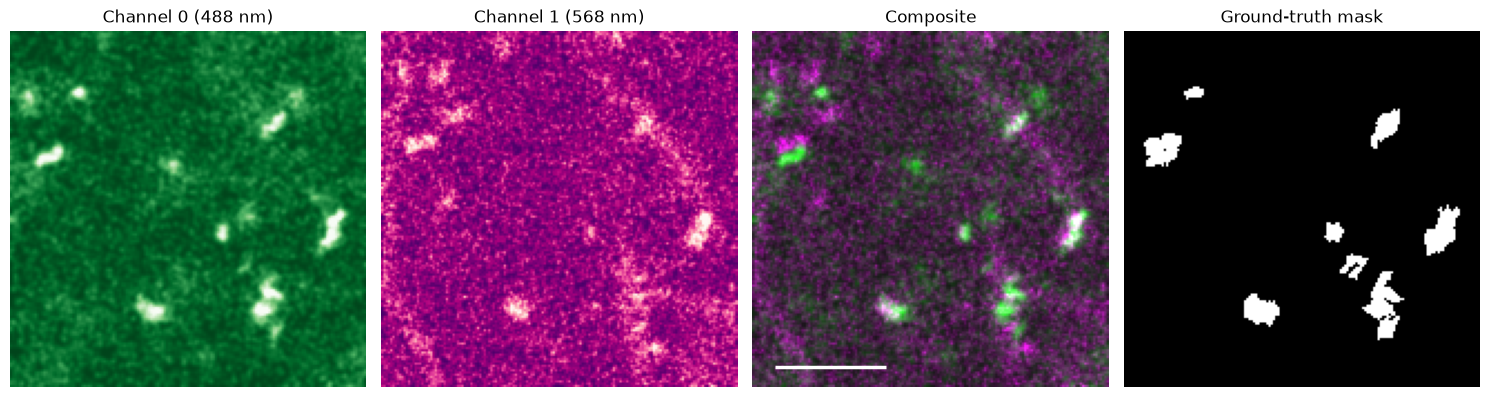

In [133]:
# Green for channel 0 and magenta for channel 1: this pair stays distinguishable
# under red-green color-vision deficiencies, unlike the conventional red/green.
composite = np.clip(np.stack([ch1, ch0, ch1], axis=-1), 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, image, title, cmap in [
    (axes[0], ch0, "Channel 0 (488 nm)", "Greens_r"),
    (axes[1], ch1, "Channel 1 (568 nm)", "RdPu_r"),
    (axes[2], composite, "Composite", None),
    (axes[3], mask0 | mask1, "Ground-truth mask", "gray"),
]:
    ax.imshow(image, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

# Scale bar on the composite.
scale_bar_px = 5.0 / (SYNAPSE_RESOLUTION * 1e6)  # 5 um, with SYNAPSE_RESOLUTION in meters per pixel.
axes[2].plot([SYNAPSE_SIZE * 0.06, SYNAPSE_SIZE * 0.06 + scale_bar_px],
             [SYNAPSE_SIZE * 0.94, SYNAPSE_SIZE * 0.94],
             color="white", linewidth=2.5, solid_capstyle="butt")

plt.tight_layout()
plt.show()

Because both channels derive from the same anchor, the ground truth of a colocalization task, i.e. which green punctum belongs to which magenta one, is known exactly.

The same idea in miniature: the cell below keeps only the anchor, the two shifted channels and the two optics, dropping the backgrounds, the deformation and the masks. The physics of the pairing is identical; everything above it is there to make the image look experimental.

### 5. Going further

The same scatterer → optics → noise recipe covers a lot more ground. Two worked examples from the DeepTrack2 [tutorials](https://github.com/DeepTrackAI/DeepTrack2/tree/develop/tutorials/1-getting-started) are worth a look:

- **[Giant Unilamellar Vesicles](https://github.com/DeepTrackAI/DeepTrack2/blob/develop/tutorials/1-getting-started/DTGS185_fig1e_GUVs.ipynb)** (`DTGS185_fig1e_GUVs.ipynb`): membrane vesicles imaged in fluorescence, built as thin shells rather than filled volumes. A good example of how far you can get by only changing the geometry of the scatterer.
- **[Electron microscopy](https://github.com/DeepTrackAI/DeepTrack2/blob/develop/tutorials/1-getting-started/DTGS187_fig1g_TEM.ipynb)** (`DTGS187_fig1g_TEM.ipynb`): a TEM micrograph with a Voronoi-based membrane network and mitochondria-like bodies. There is no point spread function and no fluorophores here, so no optical device applies: the image is generated entirely from **custom textures**, written as ordinary `dt.Feature` subclasses.

### 6. Discussion
We went from a single point emitter to a full simulation of stained nuclei, ready to train a network without annotating a single image. The pipeline was the same throughout:

**scatterer → optics → noise → image + ground truth**

Only the scatterer and the optical device changed along the way.

**Which simulation choices matter?** Vary one aspect of the simulation in 2.2, retrain in the training notebook, and compare what you find with the rest of the group. Some parameters barely affect the result, while others break the model as soon as they stop matching the real data. A useful rule of thumb is that the simulation does not need to be beautiful, but it does need to **cover** the variability of the real images: when in doubt, randomize a parameter over a wider range than you expect to encounter.

**Could you build this for your own problem?** The recipe transfers directly: describe your object as a scatterer, or write your own if none of the built-in shapes fits, pick the optical device matching your microscope, match the pixel size, and reproduce the noise of your camera.

**When is simulated data a reasonable substitute for annotated data?** It works best when the imaging physics is well understood, the objects can be described with a handful of parameters, and annotation is slow, unreliable or outright impossible, as with sub-pixel positions or dense 3D samples. It gets harder when the appearance of the objects is too complex to model, although even then a simulated dataset is often a good starting point to pre-train a model before fine-tuning it on a few annotated images.